In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.velocity_transformations import equatorial_UVW
from Distant_SigMA.SigMA.SigMA import SigMA
from Distant_SigMA.SigMA import DensityEstimator
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.cluster import normalized_mutual_info_score as nmi
from scipy.stats import skew, skewtest
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import kneighbors_graph

# Generate mock data

In [4]:
# Plotting related stuff
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

In [5]:
# Create 6D Gaussian data
np.random.seed(42) 
n = 1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50 #background dataset of random points uniformly distributed 6D

mu = np.array([-5, 5, 5, 5, -5, 5]) #first 3 for average position of the Cluster in 3D(XYZ). Last 3 for average velocities in (VxVyVz)
c_xx = c_yy = 20 #Variance of the average in x and y.
c_xy = 15 
c_zz = 3
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy #makes positive correlation of x and y
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2) #generate n/2 data points based on mu and cov

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

# Additional clusters' parameters
# Cluster 3
mu_3 = np.array([-12, 10, -10, -10, 15, -18])
c_xx_3 = c_yy_3 = 25 # More spread in X-Y plane
c_xy_3 = 10
c_zz_3 = 4
cov_3 = np.diag([c_xx_3, c_yy_3, c_zz_3, c_uvw, c_uvw, c_uvw])
cov_3[0, 1] = cov_3[1, 0] = c_xy_3
X_sig_3 = np.random.multivariate_normal(mu_3, cov_3, n//2)

# Cluster 4
mu_4 = np.array([-11, -10, 13, -7, -7, 18])
c_xx_4 = c_yy_4 = 30
c_xy_4 = -12
c_zz_4 = 5
cov_4 = np.diag([c_xx_4, c_yy_4, c_zz_4, c_uvw, c_uvw, c_uvw])
cov_4[0, 1] = cov_4[1, 0] = c_xy_4
X_sig_4 = np.random.multivariate_normal(mu_4, cov_4, n//2)

# Cluster 5
mu_5 = np.array([10, 10, 15, 10, -15, -20])
c_xx_5 = c_yy_5 = 32
c_xy_5 = 8
c_zz_5 = 6
cov_5 = np.diag([c_xx_5, c_yy_5, c_zz_5, c_uvw, c_uvw, c_uvw])
cov_5[0, 1] = cov_5[1, 0] = c_xy_5
X_sig_5 = np.random.multivariate_normal(mu_5, cov_5, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2, X_sig_3, X_sig_4, X_sig_5], axis=0) #5000 bg stars, and 5*500 cluster stars
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2, np.ones(n//2)*3, np.ones(n//2)*4, np.ones(n//2)*5]).astype(int)

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_cluster_3 = np.where(labels==3)[0]
idx_cluster_4 = np.where(labels==4)[0]
idx_cluster_5 = np.where(labels==5)[0]
idx_bg = np.where(labels==0)[0]

A = kneighbors_graph(df[['x', 'y', 'z']].values, n_neighbors=50, mode='distance', n_jobs=-1)

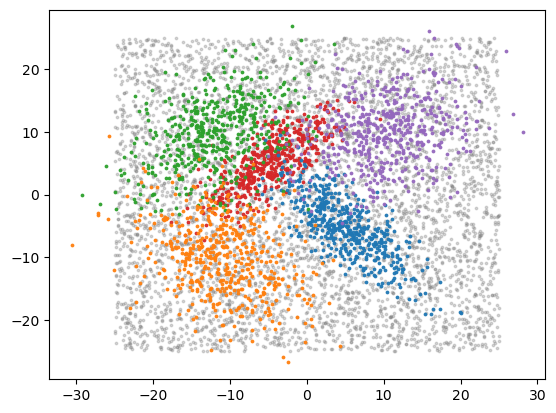

In [6]:
x_col, y_col = 'x', 'y'
#x_col, y_col = 'vx', 'vy'
#x_col, y_col = 'vt_ra', 'vt_dec'
#x_col, y_col = 'pmra', 'pmdec'
for idx_sel, alpha, c, zo in zip([idx_cluster_1, idx_cluster_2, idx_cluster_3, idx_cluster_4, idx_cluster_5, idx_bg], alphas, colors, zorders): 
    plt.scatter(df.loc[idx_sel, x_col], df.loc[idx_sel, y_col], s=3, c=c, alpha=alpha, zorder=zo)

In [7]:
U, V, W = equatorial_UVW(
    ra,
    dec,
    pmra,
    pmdec,
    rv_calc,
    dist,
)
# Check if the transformation is correct
np.allclose(U, df.vx.values, atol=1e-1), np.allclose(V, df.vy.values, atol=1e-1), np.allclose(W, df.vz.values, atol=1e-1)
df.to_csv('data.csv', index=False)

# Apply TreeSigMA

In [9]:
from TreeSigMA import TreeSigMAWithHierarchy  

knn_list=[15, 20, 25, 30]
cluster_features=['x', 'y', 'z']
sigma_kwargs = dict(
        nb_resampling=0,
        max_knn_density=int(np.max(knn_list)+1),
        beta=0.99,
        knn_initcluster_graph=35
    )

# Initialize TreeSigMA
tree_sigma = TreeSigMAWithHierarchy(
    data=df,
    cluster_features=cluster_features,
    **sigma_kwargs
)

# Run the SigMA clustering and build the hierarchy
print("Running TreeSigMA clustering...")
alpha_values = tree_sigma.run()
print("Clustering completed. Alpha values:", alpha_values)

# Build hierarchy 
print("\nBuilding hierarchy...")
tree_sigma.build_hierarchy()
print("Hierarchy built.")

# Traverse the tree
print("\nTop-down traversal:")
for node in tree_sigma.hierarchy.traverse_top_down():
    print(f"Node ID: {node.node_id}, Parent: {node.parent.node_id if node.parent else None}, "
          f"Children: {[child.node_id for child in node.children]}") # evt. , Data: {node.data}

print("\nBottom-up traversal:")
for node in tree_sigma.hierarchy.traverse_bottom_up():
    print(f"Node ID: {node.node_id}, Parent: {node.parent.node_id if node.parent else None}, "
          f"Children: {[child.node_id for child in node.children]}") # evt. , Data: {node.data}

# Access a specific node and analyze
print("\nInspecting a specific node...")
node_id = list(tree_sigma.hierarchy.nodes.keys())[0]  # Pick the desired node ID
node = tree_sigma.hierarchy.nodes[node_id]
print(f"Node ID: {node.node_id}")
print(f"Parent ID: {node.parent.node_id if node.parent else 'Root'}")
print(f"Children IDs: {[child.node_id for child in node.children]}")
#print(f"Data: {node.data}")

# Example: Analyzing the leaves
print("\nAnalyzing leaves:")
leaves = [node for node in tree_sigma.hierarchy.traverse_top_down() if node.is_leaf()]
for leaf in leaves:
    print(f"Leaf ID: {leaf.node_id}")

Performing gradient ascend using a 20-NN density estimation.
Running TreeSigMA clustering...
Clustering completed. Alpha values: [8.358314040890491e-13, 7.849489391809072e-10, 0.008350465821492625, 0.017127265996220442, 0.024698097782602402, 0.03752241188654126, 0.04748529519762862, 0.07662375372192787, 0.10769685157837172, 0.12792206847670234, 0.14806420550879157, 0.1663054183057111, 0.1865651302903229, 0.19707690418024099]

Building hierarchy...
Hierarchy built.

Top-down traversal:
Node ID: virtual_root, Parent: None, Children: ['5485_0', '5701_0', '6473_0']
Node ID: 5485_0, Parent: virtual_root, Children: ['5485_1', '7293_1']
Node ID: 5485_1, Parent: 5485_0, Children: ['5485_2', '6974_2']
Node ID: 5485_2, Parent: 5485_1, Children: ['5010_7', '5485_7']
Node ID: 5010_7, Parent: 5485_2, Children: []
Node ID: 5485_7, Parent: 5485_2, Children: ['5203_9', '5485_9']
Node ID: 5203_9, Parent: 5485_7, Children: []
Node ID: 5485_9, Parent: 5485_7, Children: ['5247_10', '5485_10']
Node ID: 524

# Plot the Hierarchy

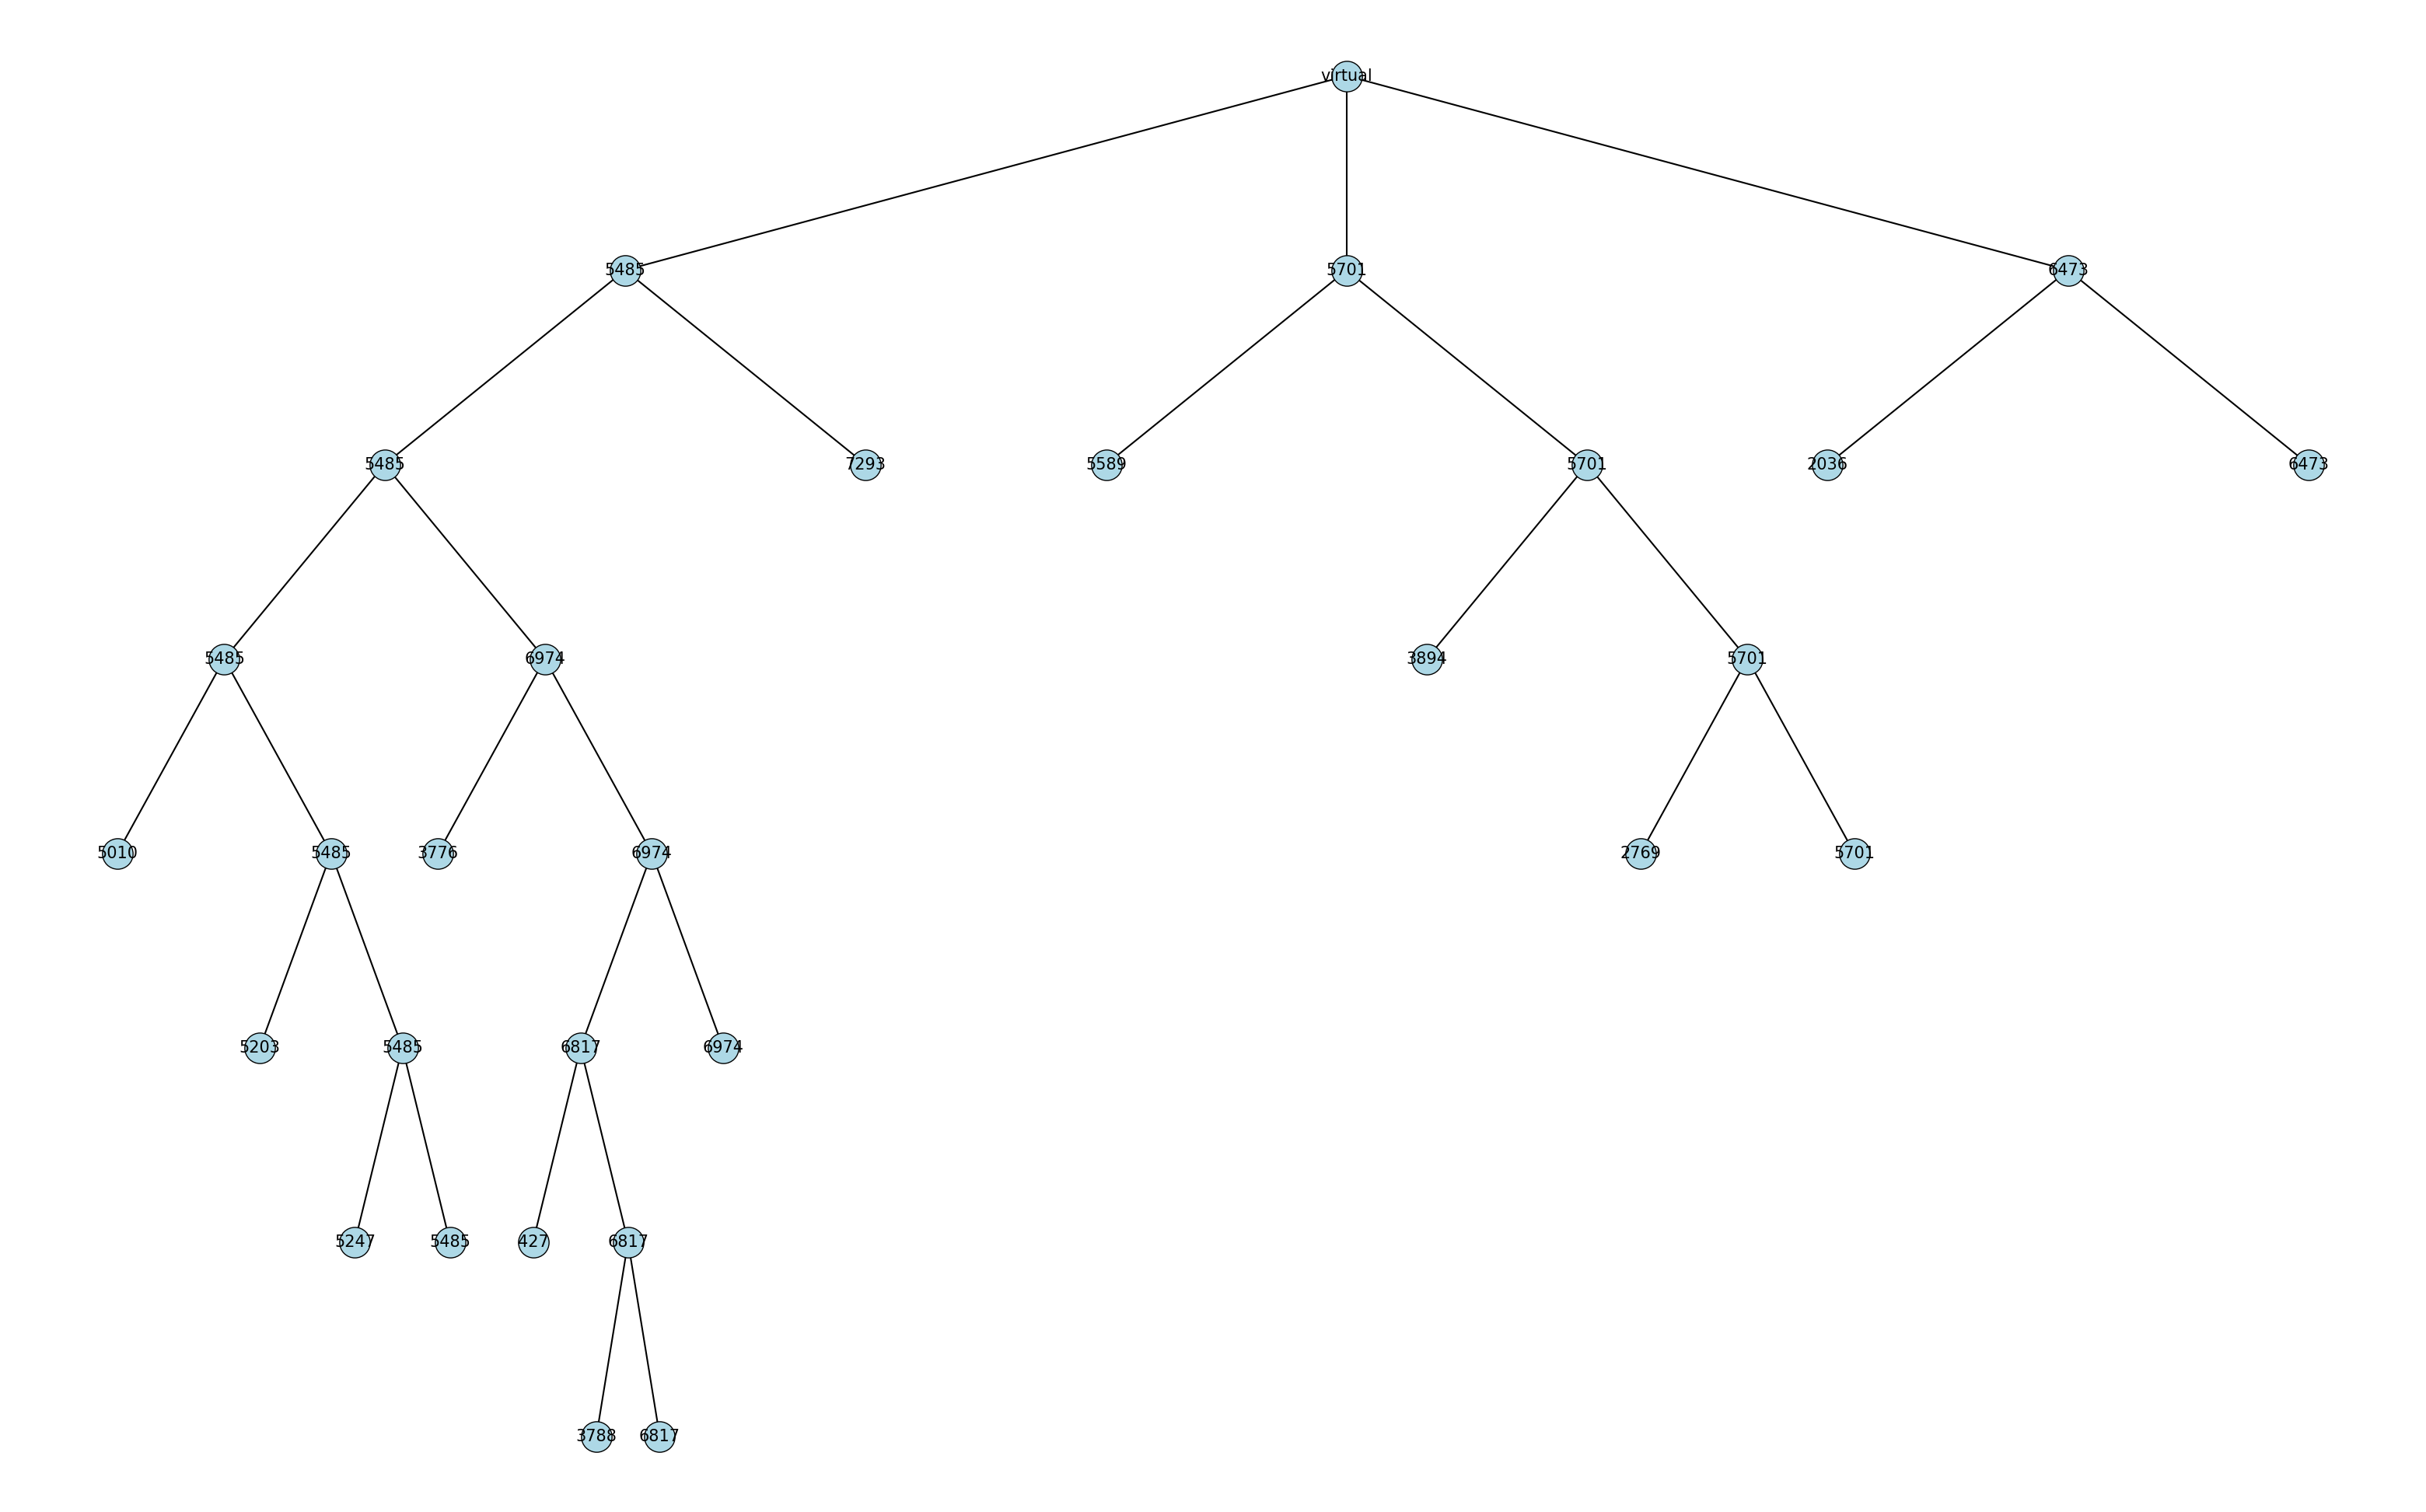

In [11]:
def plot_tree(node, x=0, y=0, level=0, x_spacing=1.5, y_spacing=1.5, node_positions=None, parent_positions=None, parent=None):
    """
    Recursively plot tree structure
    
    Args:
        node (TreeNode): The current node to plot.
        x (float): X-coordinate of the current node.
        y (float): Y-coordinate of the current node.
        level (int): Current level in the tree.
        x_spacing (float): Horizontal spacing between nodes.
        y_spacing (float): Vertical spacing between levels.
        node_positions (dict): Dictionary to store node positions for plotting.
        parent_positions (dict): Dictionary to store parent positions for edges.
        parent (tuple): Position of the parent node.
    """
    if node_positions is None:
        node_positions = {}
    if parent_positions is None:
        parent_positions = []

    # Store the current node's position
    node_positions[node.node_id] = (x, y)
    if parent is not None:
        parent_positions.append((parent, (x, y)))

    # Compute positions for children
    n_children = len(node.children)
    for i, child in enumerate(node.children):
        child_x = x - x_spacing * (n_children - 1) / 2 + i * x_spacing
        child_y = y - y_spacing
        plot_tree(child, x=child_x, y=child_y, level=level + 1,
                  x_spacing=x_spacing / 1.5, y_spacing=y_spacing,
                  node_positions=node_positions, parent_positions=parent_positions,
                  parent=(x, y))
    
    # Plot when at the root level
    if level == 0:
        fig, ax = plt.subplots(figsize=(40, 25))
        for (start, end) in parent_positions:
            ax.plot([start[0], end[0]], [start[1], end[1]], 'k-', zorder=1)
        for node_id, (nx, ny) in node_positions.items():
            current_node = tree_sigma.hierarchy.nodes[node_id]
            original_label = current_node.node_id.split('_')[0] # Get the original_label
            ax.scatter(nx, ny, s=800, c='lightblue', edgecolors='black', zorder=2)
            #ax.text(nx, ny, str(node_id), fontsize=10, ha='center', va='center', zorder=3)
            ax.text(nx, ny, f"{original_label}", fontsize=15, ha='center', va='center', zorder=3)
        ax.axis('off')
        plt.savefig('TreeSigMA.png')
        plt.show()

plot_tree(tree_sigma.hierarchy.root)

## Plot the data in each node

In [80]:
import os

# Create a directory to save the plots
output_dir = "TreeNode_XY_Plots"
os.makedirs(output_dir, exist_ok=True)

# Define colors for each true label
cols = {0: 'tab:grey', 1: 'tab:red', 2: 'tab:blue', 3: 'tab:green', 4: 'tab:orange', 5: 'tab:purple'}

alphas = {0: 0.3, 1: 0.9, 2: 0.9, 3: 0.9}
zorders = {0: 0, 1: 1, 2: 1, 3: 1}

def plot_node_data(node, df, labels, output_dir, x_col='x', y_col='y'):
    """
    Plot the data points contained in a tree node, colored by true labels.

    Args:
        node (TreeNode): Tree node to plot.
        df (pd.DataFrame): Dataframe containing the data points.
        labels (np.ndarray): Array of true labels.
        output_dir (str): Directory to save the plots.
        x_col (str): Column name for x-axis data.
        y_col (str): Column name for y-axis data.
    """
    indices = node.data_indices
    if len(node.data_indices) == 0: #skip virtual node
        return
        
    node_data = df.iloc[indices]
    node_labels = labels[indices]

    plt.figure(figsize=(8, 6))
    for label, color in cols.items():
        mask = node_labels == label
        plt.scatter(node_data.loc[mask, x_col],
                    node_data.loc[mask, y_col], 
                    s=10,c=color,
                    alpha=alphas.get(label, 0.9), 
                    zorder=zorders.get(label, 1),
                    label=f'Label {label}'
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Node ID: {node.node_id}")
    plt.legend(fontsize=12, markerscale = 2)
   # plt.show()

    # Save plot
    plt.savefig(os.path.join(output_dir, f"Node_{node.node_id}.png"))
    plt.close()

# Generate plots for each tree node
for node in tree_sigma.hierarchy.traverse_top_down():
    plot_node_data(node, df, labels, output_dir)

# Prune the Tree

In [82]:
#postprocessing the tree - if cluster got less than star_threshold stars, remove children from tree (if they are leaves)
X = df[['x', 'y', 'z']].values
pruned_tree = tree_sigma.prune_tree(star_threshold=20, X=X)

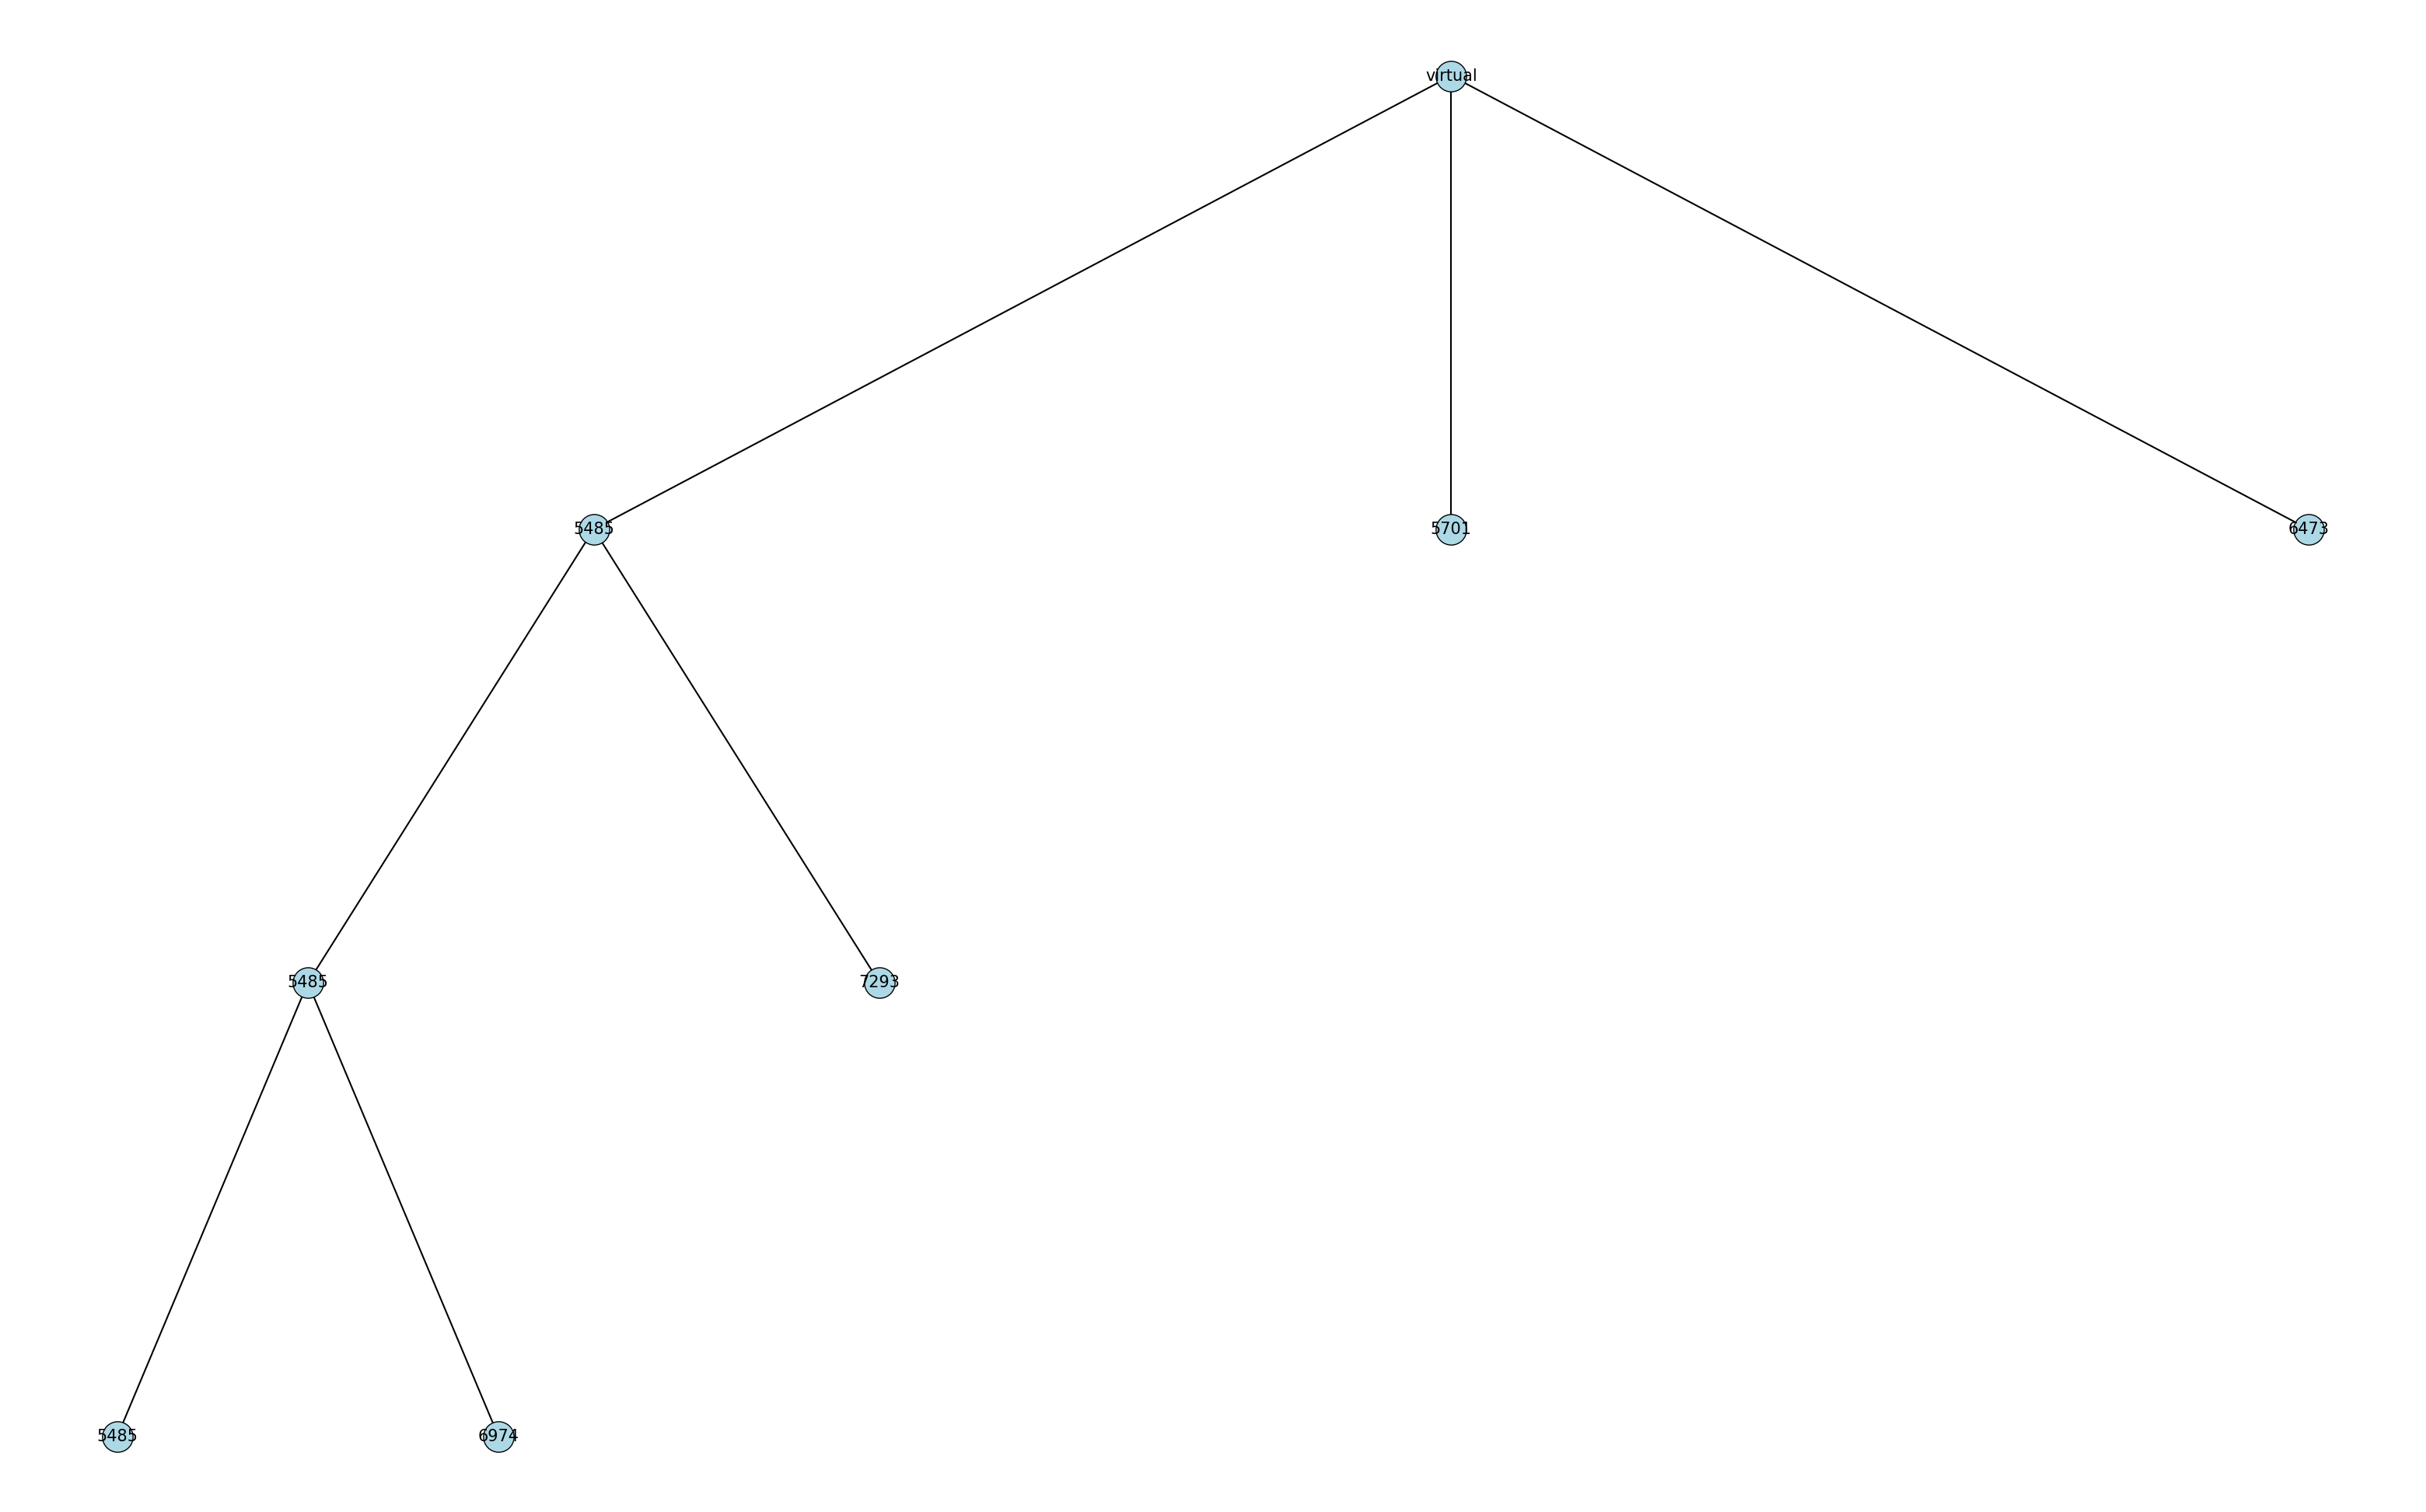

In [84]:
plot_tree(pruned_tree.hierarchy.root)

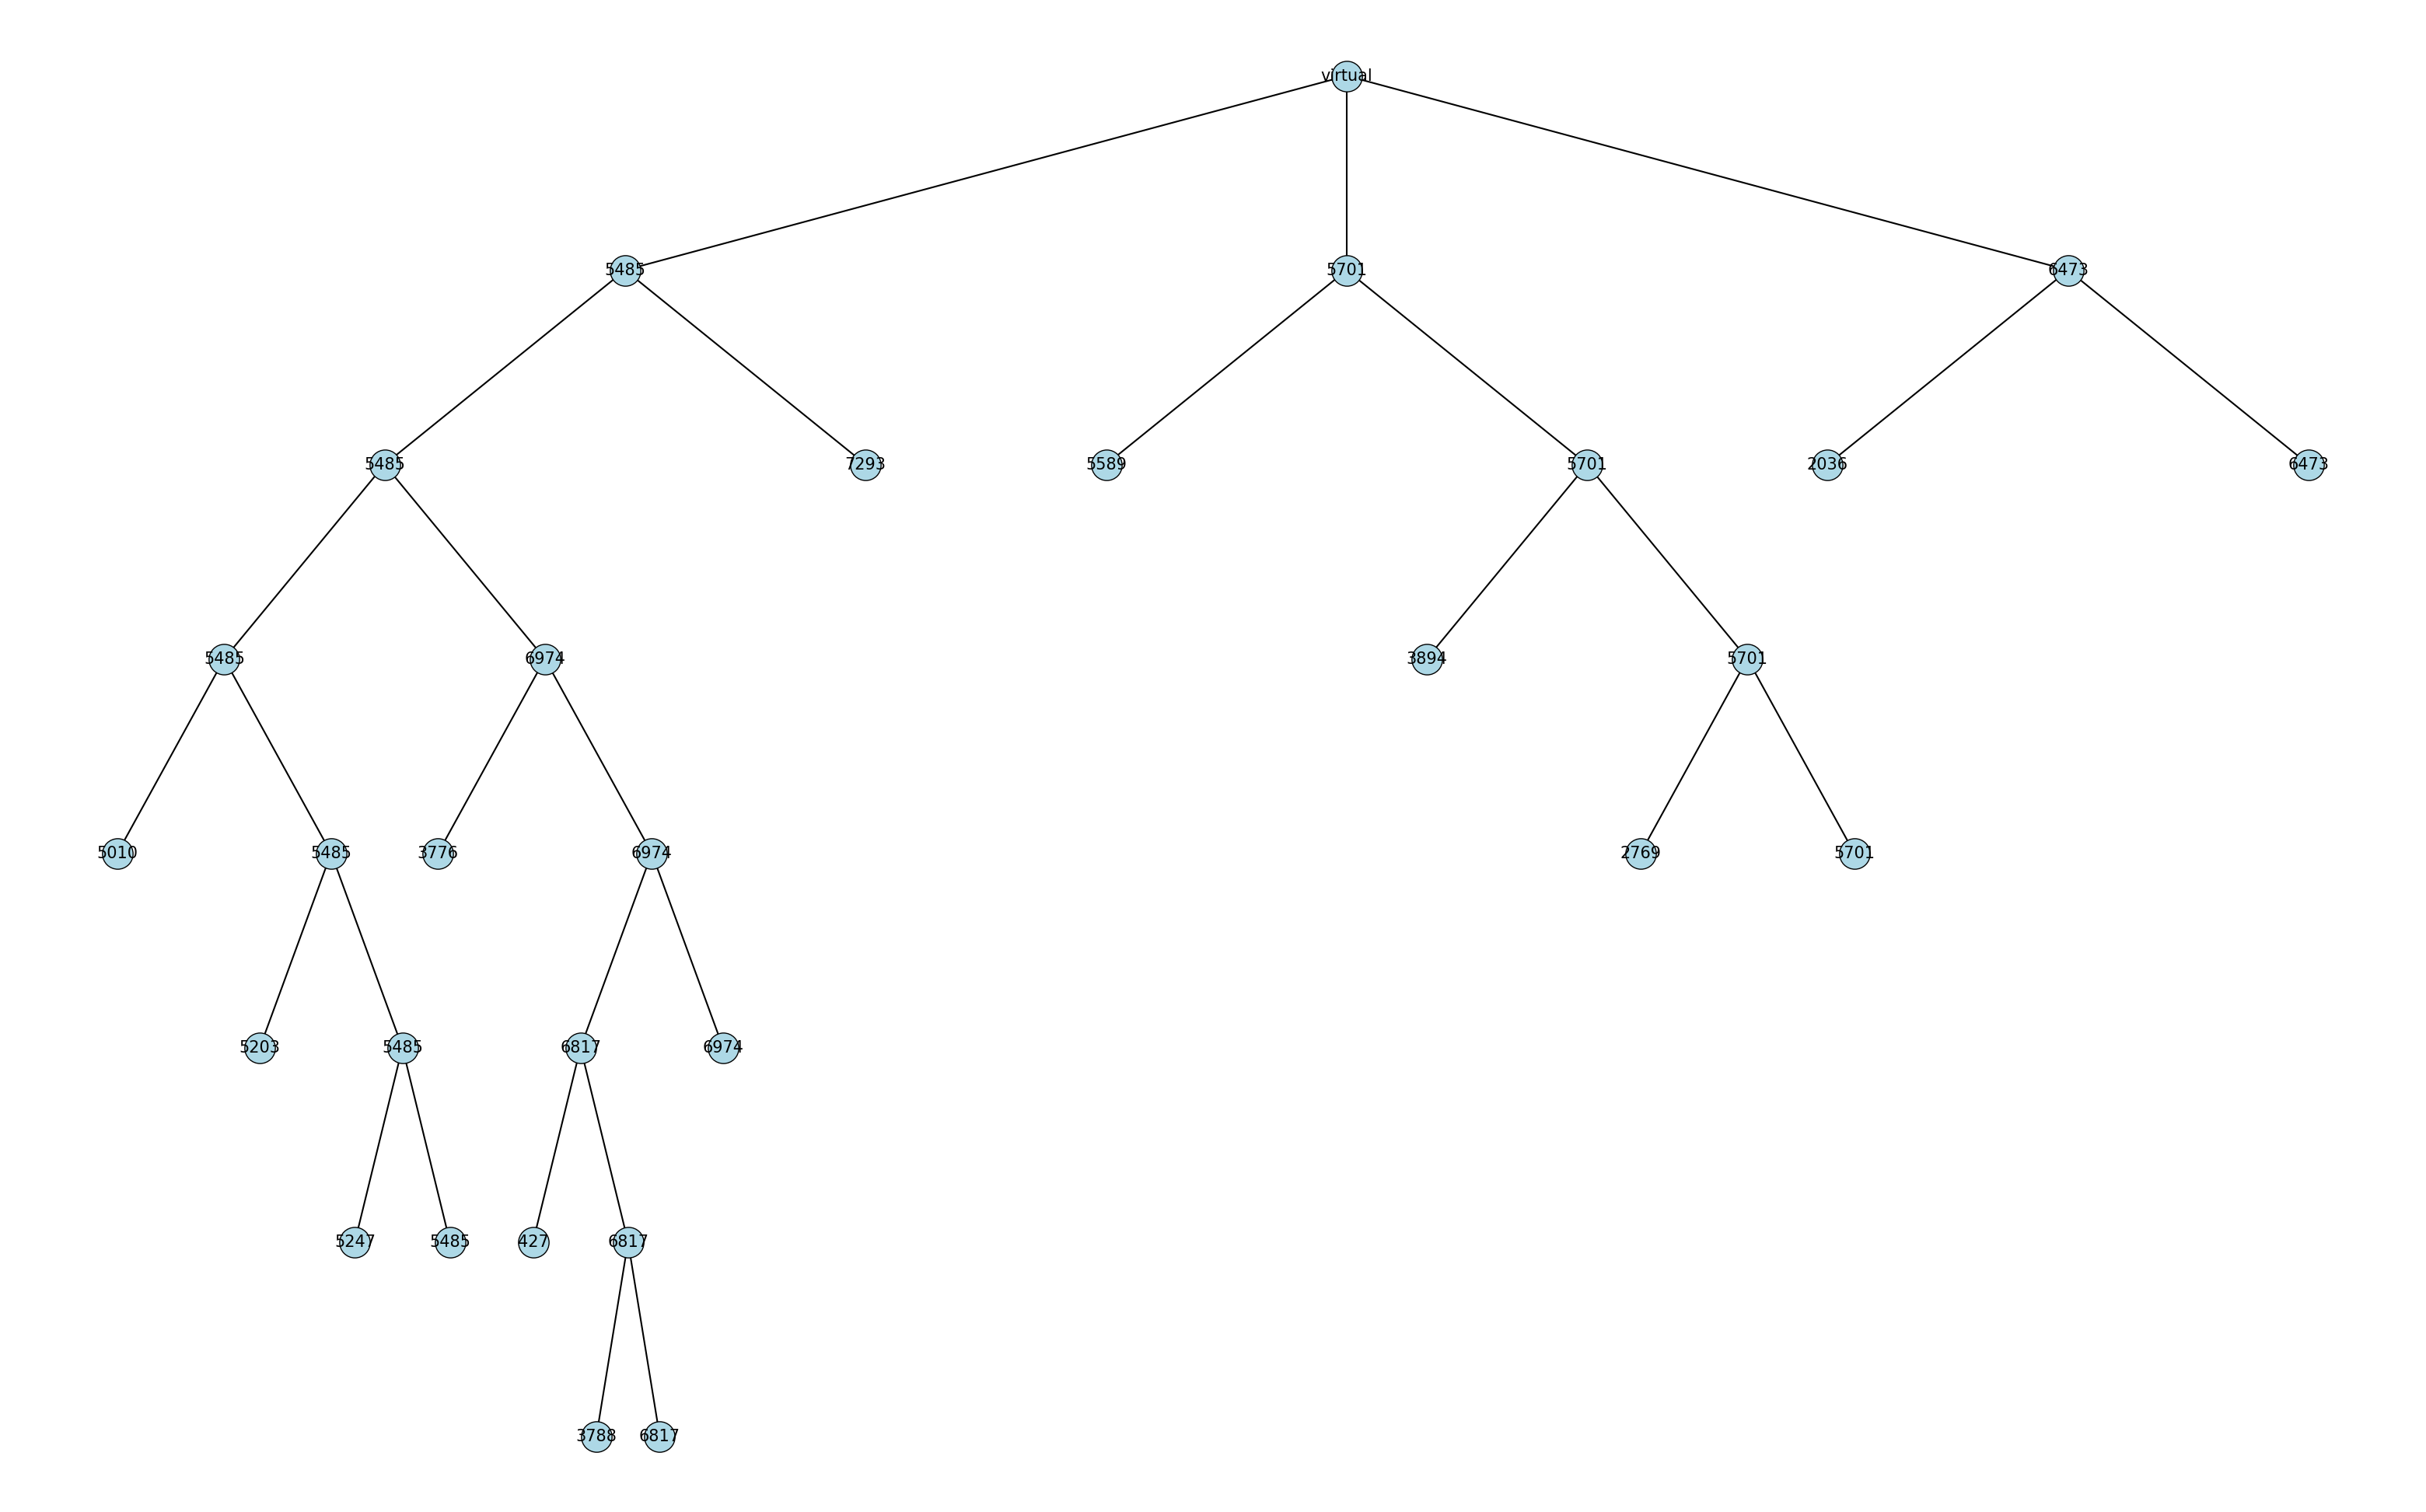

In [17]:
plot_tree(tree_sigma.hierarchy.root)

In [18]:
for uid in pruned_tree.hierarchy.nodes:
    print(f"Node {uid}: {pruned_tree.hierarchy.nodes[uid].alpha_levels}")  

Node virtual_root: []
Node 5485_0: [0]
Node 5701_0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 6473_0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 5485_1: [1]
Node 7293_1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 5485_2: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 6974_2: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [19]:
for uid in tree_sigma.hierarchy.nodes:
            print(f"Node {uid}: {tree_sigma.hierarchy.nodes[uid].alpha_levels}")  

Node virtual_root: []
Node 5485_0: [0]
Node 5701_0: [0, 1, 2, 3, 4]
Node 6473_0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Node 5485_1: [1]
Node 7293_1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 5485_2: [2, 3, 4, 5, 6]
Node 6974_2: [2]
Node 3776_3: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 6974_3: [3]
Node 6817_4: [4, 5, 6, 7]
Node 6974_4: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 5589_5: [5, 6, 7, 8, 9, 10, 11, 12, 13]
Node 5701_5: [5]
Node 3894_6: [6, 7, 8, 9, 10, 11, 12, 13]
Node 5701_6: [6, 7, 8, 9, 10, 11, 12]
Node 5010_7: [7, 8, 9, 10, 11, 12, 13]
Node 5485_7: [7, 8]
Node 427_8: [8, 9, 10, 11, 12, 13]
Node 6817_8: [8, 9, 10]
Node 5203_9: [9, 10, 11, 12, 13]
Node 5485_9: [9]
Node 5247_10: [10, 11, 12, 13]
Node 5485_10: [10, 11, 12, 13]
Node 3788_11: [11, 12, 13]
Node 6817_11: [11, 12, 13]
Node 2036_12: [12, 13]
Node 6473_12: [12, 13]
Node 2769_13: [13]
Node 5701_13: [13]


## Plot tree with percentages of ground truth clusters and percentage of noise

In [21]:
def plot_tree_with_percentages(tree, node, df, labels, cols, x=0, y=0, level=0, 
                                                      x_spacing=1.5, y_spacing=1.5, 
                                                      node_positions=None, parent_positions=None, parent=None):
    if node_positions is None:
        node_positions = {}
    if parent_positions is None:
        parent_positions = []

    # Store the current node's position
    node_positions[node.node_id] = (x, y)
    if parent is not None:
        parent_positions.append((parent, (x, y)))

    # Compute percentages for background and clusters
    indices = node.data_indices
    label_counts = {label: 0 for label in np.unique(labels)}
    if len(indices) > 0:
        node_labels = labels[indices]
        unique_labels, counts = np.unique(node_labels, return_counts=True)
        label_counts.update(dict(zip(unique_labels, counts)))
        total_in_node = len(indices)

        # Compute percentages for background and each cluster
        total_background_points = np.sum(labels == 0)
        percentages = {}
        for label, count in label_counts.items():
            if label == 0:  # Background
                percentages[label] = (count / total_in_node) * 100  # Percentage in node
            else:  # Cluster points
                total_cluster_points = np.sum(labels == label)
                percentages[label] = (count / total_cluster_points) * 100  # Percentage relative to cluster
    else:
        percentages = None

    # Prepare the text for the node
    if percentages:
        text_lines = [
            f"{label}: {percent:.1f}%" for label, percent in percentages.items()
        ]
    else:
        text_lines = ["Virtual Node"]

    # Compute positions for children
    n_children = len(node.children)
    for i, child in enumerate(node.children):
        child_x = x - x_spacing * (n_children - 1) / 2 + i * x_spacing
        child_y = y - y_spacing
        plot_tree_with_percentages(tree,
            child, df, labels, cols, 
            x=child_x, y=child_y, level=level + 1,
            x_spacing=x_spacing / 1.5, y_spacing=y_spacing,
            node_positions=node_positions, 
            parent_positions=parent_positions, 
            parent=(x, y)
        )
    
    # Plot when at the root level
    if level == 0:
        fig, ax = plt.subplots(figsize=(20, 12))
        for (start, end) in parent_positions:
            ax.plot([start[0], end[0]], [start[1], end[1]], 'k-', zorder=1)
        for node_id, (nx, ny) in node_positions.items():
            current_node = tree.hierarchy.nodes[node_id]
            indices = current_node.data_indices
            indices
            label_counts = {label: 0 for label in np.unique(labels)}
            if len(indices) > 0:
                node_labels = labels[indices]
                unique_labels, counts = np.unique(node_labels, return_counts=True)
                label_counts.update(dict(zip(unique_labels, counts)))
                total_in_node = len(indices)

                # Compute percentages for background and each cluster
                percentages = {}
                for label, count in label_counts.items():
                    if label == 0:  # Background
                        percentages[label] = (count / total_in_node) * 100  # Percentage in node
                    else:  # Cluster points
                        total_cluster_points = np.sum(labels == label)
                        percentages[label] = (count / total_cluster_points) * 100  # Percentage relative to cluster
            else:
                percentages = None
            
            # Add text label for percentage breakdown
            if percentages:
                text_lines = [
                    f"{label}: {percent:.1f}%" for label, percent in percentages.items()
                ]
                colors = [cols[label] for label, percent in percentages.items()]
            else:
                text_lines = ["Virtual Node"]
                colors = ['black']
            
            ax.scatter(nx, ny, s=800, c='lightblue', edgecolors='black', zorder=2)
            for i, (line, color) in enumerate(zip(text_lines, colors)):
                ax.text(nx, ny - i * 0.2, line, fontsize=8, color=color, 
                        ha='center', va='center', zorder=3)
        ax.axis('off')
        plt.savefig('Tree_with_Percentages.png')
        plt.show()

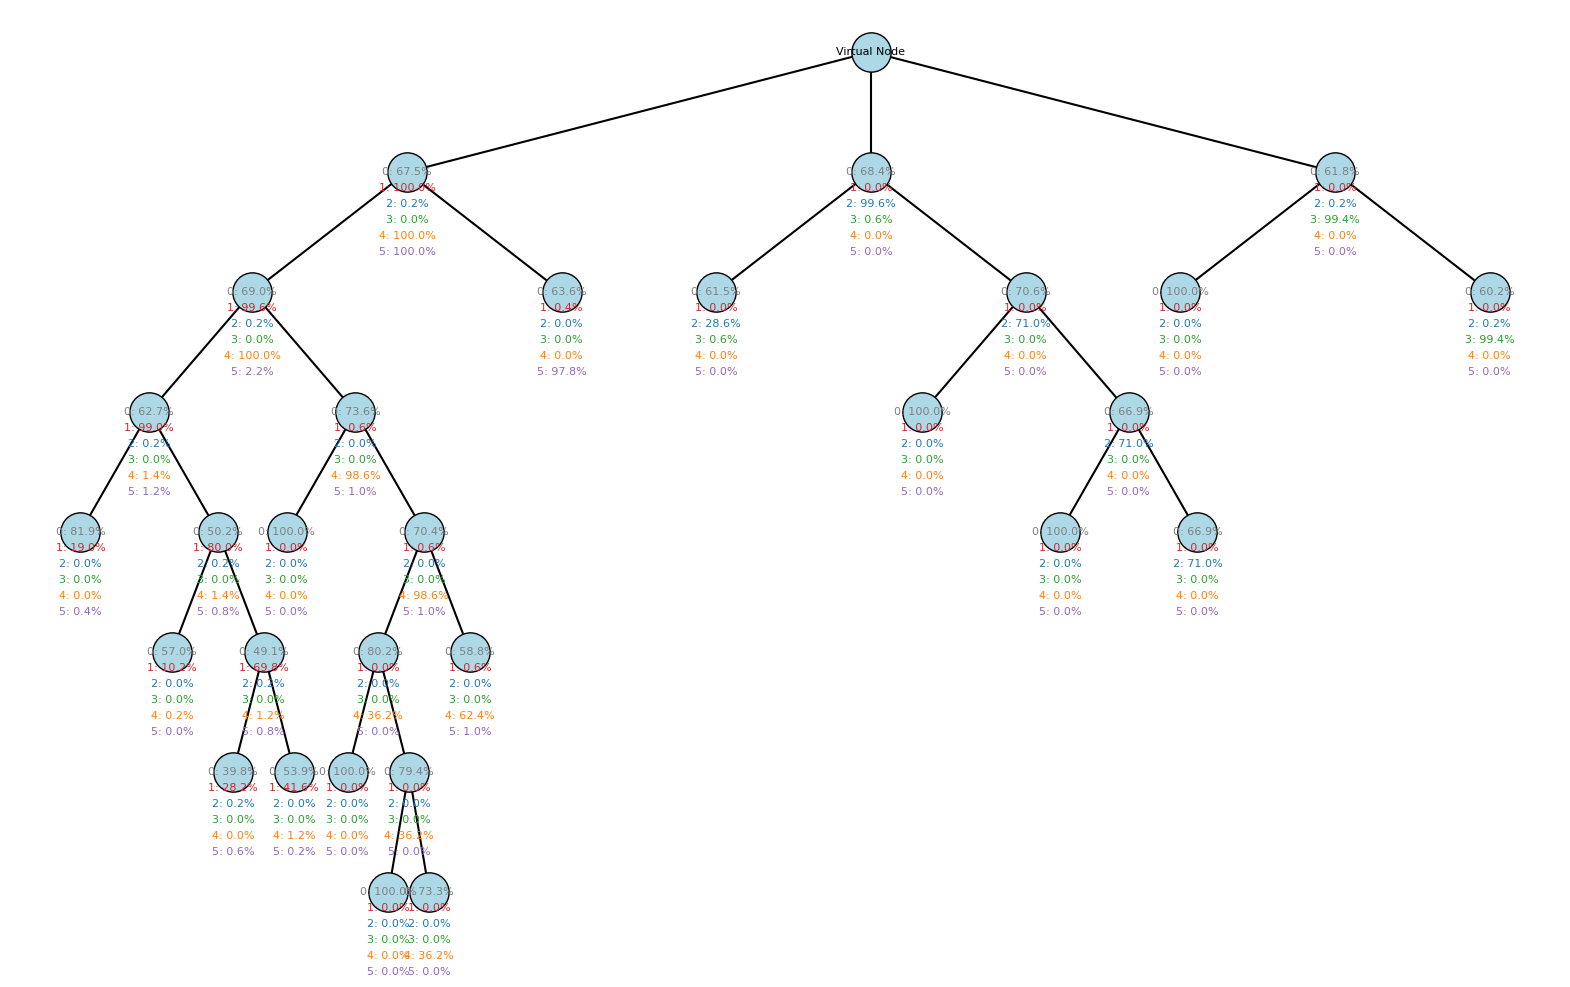

In [22]:
# Plot the tree
plot_tree_with_percentages(tree_sigma, tree_sigma.hierarchy.root, df, labels, cols)

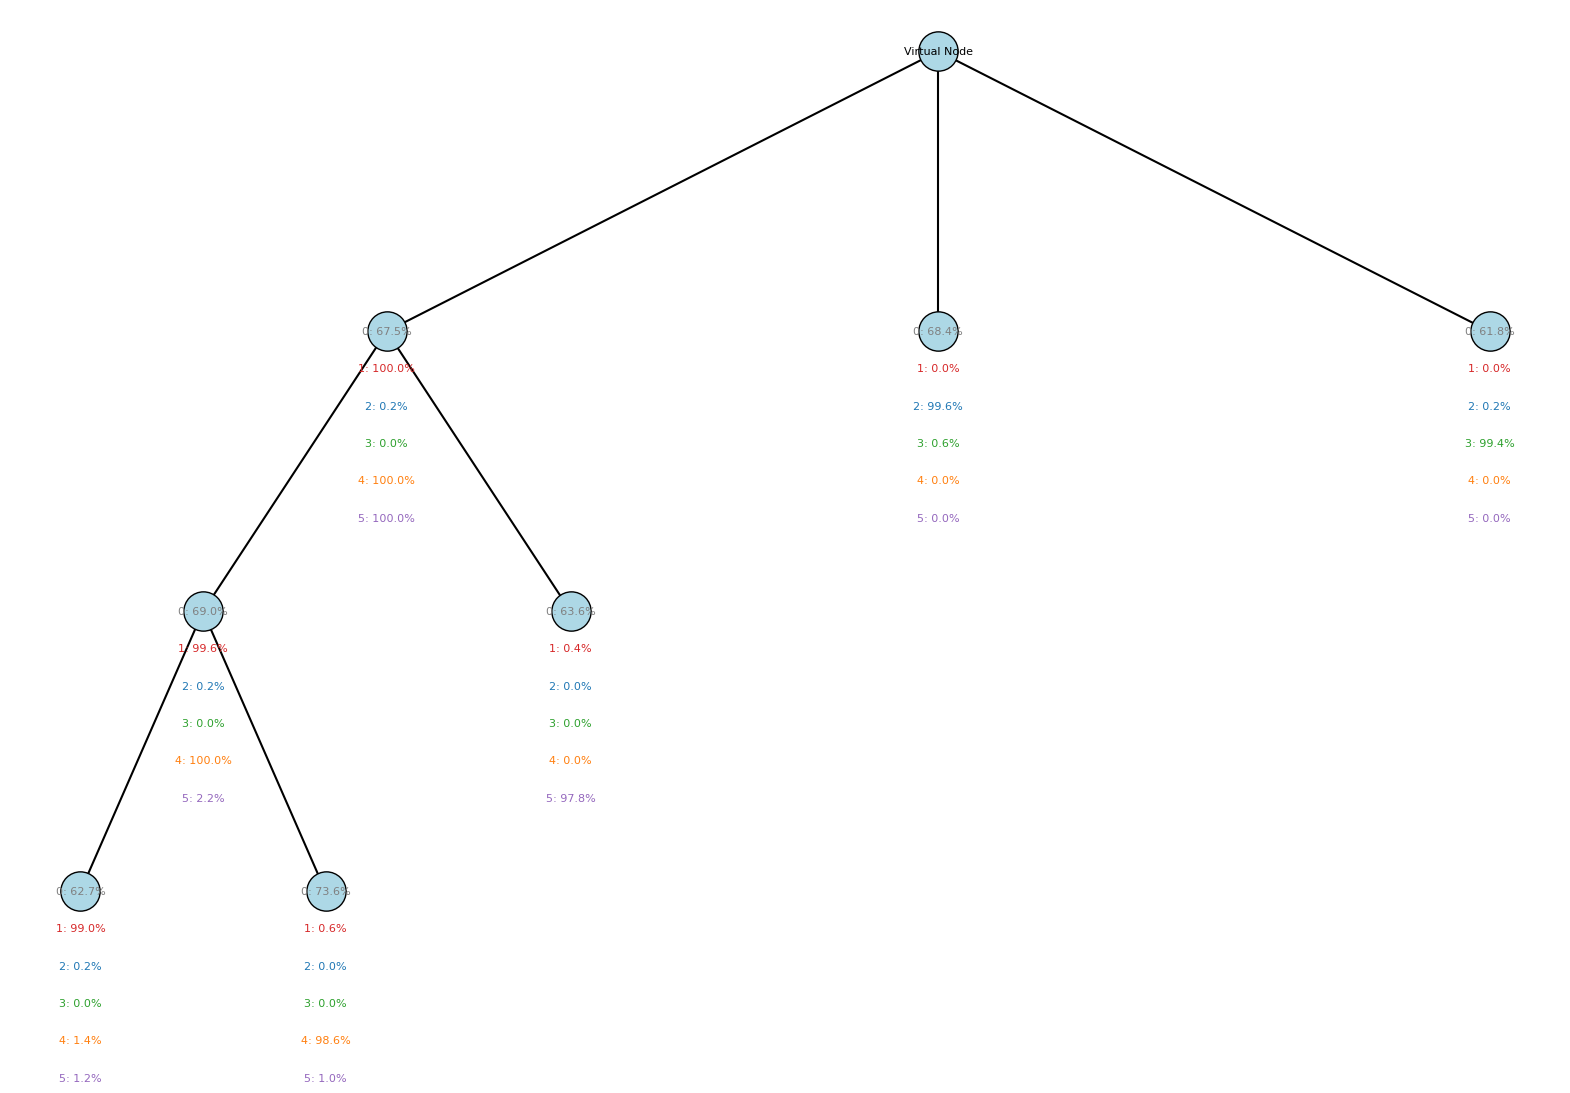

In [23]:
# Plot the pruned tree
plot_tree_with_percentages(pruned_tree, pruned_tree.hierarchy.root, df, labels, cols)

# Run Softmax in each node (Sebastians class)

In [25]:
import SemiMetricClustering.SemiMetricDensity as sm

In [26]:
node_indices = pruned_tree.hierarchy.get_all_indices() #list containing arrays of indices for each node
spec_node = 0

In [27]:
cluster_results = []
df.rename(columns={'x': 'X', 'y': 'Y', 'z': 'Z'}, inplace=True)

#for i, indices in enumerate(node_indices):
    
smc = sm.SemiMetricDensity(data=df, K=4, max_iter=1_000, method="random")

smc.compute_G(node_indices[spec_node])
p_labels, z = smc.run_softmax(
    initial_partition=None, theta=0.01, epsilon=0.005, rho_multiplier=np.ones(node_indices[spec_node].size, dtype=np.float32), verbose=True
)
labels_smc = smc.get_clusters(p_labels)
   
  #  labels_smc, z = smc.fit(
        # ATTENTION: Here you specify the indices of the data points you want to run softmax on
        # If you want to run on all data points, set indices=None. Otherwise, pass a numpy array containing the target indices
   #     indices=indices,
        # remaining parameters
    #    theta=0.01, epsilon=0.005, init_features=['x', 'y', 'z'], #epsilon must be smaller than theta 
    #    expected_signal_percentage=0.09, transition_speed=20,#ts 10-50 
        # not important parameters, do not change for now
    
    #    verbose=True, run_trial=True, A=A, dx=0.01
  #  )
cluster_results.append((labels_smc, node_indices[spec_node]))

Initializing probabilities randomly with 4 clusters...
Number of softmax iterations: 24


### plot sofmax clusters of each node

In [29]:
df.rename(columns={'X': 'x', 'Y': 'y', 'Z': 'z'}, inplace=True)
def plt_result_node(node_index, df, labels, true_labels, x_col='x', y_col='y', dx=2):
    """
    Plot softmax clusters for a specific node.

    node_index (int): Index of the current node.
    labels (np array): Cluster labels for the data points.
    true_labels (np array): True labels for the data points.
    dx (float): Padding for the plot axes.
    """
    unique_clusters = np.unique(labels[labels >= 0])  # Exclude -1 (unclustered points)
    n_clusters = len(unique_clusters)

    # Skip plotting if no clusters are detected
    if n_clusters == 0:
        print(f"Node {node_index + 1}: No clusters detected. Skipping.")
        return

    fig, ax = plt.subplots(1, n_clusters, figsize=(n_clusters * 5, 5))
    if n_clusters == 1:
        ax = [ax]  # Ensure consistent handling for single cluster

    cols = {0: 'tab:grey', 1: 'tab:red', 2: 'tab:blue', 3: 'tab:green', 4: 'tab:orange', 5: 'tab:purple'}

    alphas = {0: 0.3, 1: 0.9, 2: 0.9, 3: 0.9}
    zorders = {0: 0, 1: 1, 2: 1, 3: 1}

    for i, cluster in enumerate(unique_clusters):
        cluster_indices = labels == cluster
        cluster_data = df.loc[cluster_indices]
        true_label_data = true_labels[cluster_indices]

        for true_label in np.unique(true_label_data):
            true_label_indices = cluster_data[true_label_data == true_label].index
            ax[i].scatter(
                cluster_data.loc[true_label_indices, x_col],
                cluster_data.loc[true_label_indices, y_col],
                s=10,
                alpha=alphas.get(true_label, 0.7),
                zorder=zorders.get(true_label, 1),
                label= "Background" if true_label == 0 else f"True label {true_label}",
                color=cols.get(true_label)
            )

        ax[i].set_title(f"Node {node_index}, Cluster {cluster}",fontsize=20)
        ax[i].set_xlim(df[x_col].min() - dx, df[x_col].max() + dx)
        ax[i].set_ylim(df[y_col].min() - dx, df[y_col].max() + dx)
        ax[i].legend(fontsize=12, markerscale = 2)

    plt.tight_layout()
    plt.show()

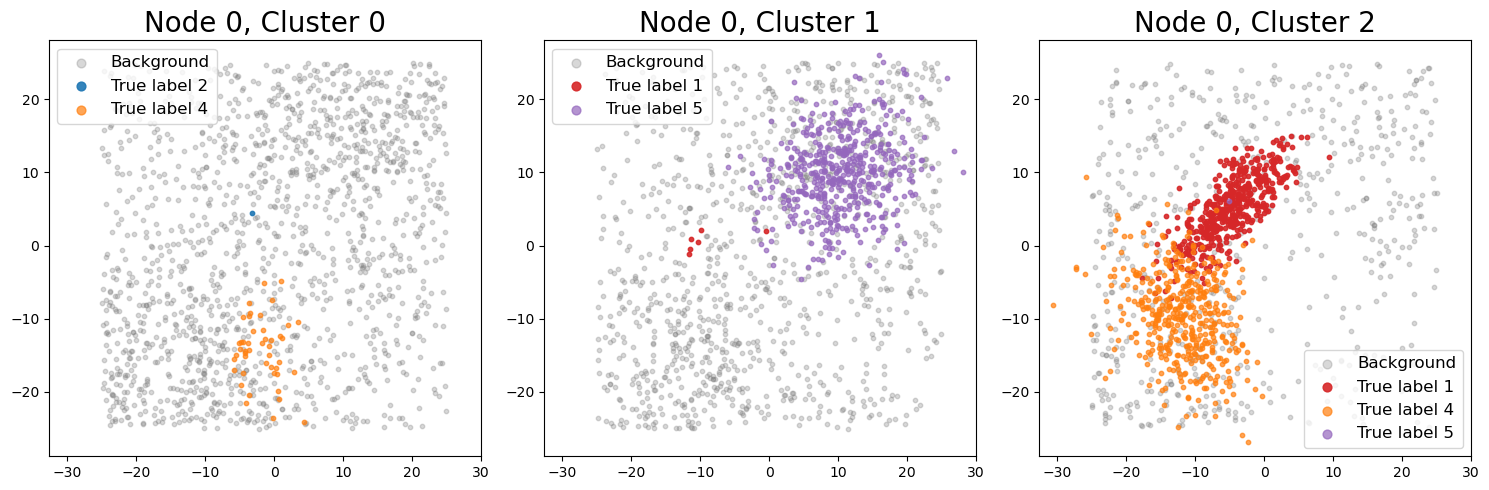

In [30]:
original_label = labels

for node_index, (labels_smc, indices) in enumerate(cluster_results):
    # Create a temporary DataFrame for the current node's data
    node_df = df.iloc[indices].copy()  # Select only the points in this node
    node_true_labels = original_label[indices]  # True labels for the selected points

    plt_result_node(
        node_index = node_index,
        df=node_df,
        labels=labels_smc,
        true_labels=node_true_labels,
        x_col='x',
        y_col='y'
    )

## Consensus Clustering

In [32]:
# Import consensus clustering
from ConcensusClustering.consensus import ClusterConsensus

In [33]:
#for i, (labels_smc, indices) in enumerate(cluster_results):
 #   cc = ClusterConsensus(np.array(labels_smc))
#    rho = compute_density_direct(df[['x', 'y', 'z']].values, k=10, agg_func=np.mean)
 #   labels_cc = cc.fit(min_frac_bg=0.8)

In [34]:
#print(f'NMI: {nmi(labels_true, labels_cc):.3f}, nb sources: {np.sum(labels_true[labels_cc>-1]>0)}/200')
#plt_result(labels_cc, x_col='x', y_col='y')

## Look into z space and MDS

### z space plotting

In [37]:
import plotly.graph_objects as go

z_0 = z[:, 0]
z_1 = z[:, 1]
z_2 = z[:, 2]  # Use the Z values

z_0_normed = (z[:, 0] - np.mean(z[:, 0])) / np.std(z[:, 0])
z_1_normed = (z[:, 1] - np.mean(z[:, 1])) / np.std(z[:, 1])
z_2_normed = (z[:, 2] - np.mean(z[:, 2])) / np.std(z[:, 2])

node_df = df.iloc[node_indices[spec_node]].copy()

node_true_labels = original_label[node_indices[spec_node]]
unique_labels = np.unique(node_true_labels)

# Define a fixed color map for each cluster
color_map = {
    0: "lightgrey",
    1: "red",
    2: "blue",
    3: "green",
    4: "orange",
    5: "purple"
}

# Assign colors based on cluster labels
point_colors = [color_map[label] for label in node_true_labels]

# Create hover text for each point
hover_text = [
    "Background" if label == 0 else f"Cluster {label}" 
    for label in node_true_labels
]
# Create the 3D scatter plot
fig = go.Figure(data=[
    go.Scatter3d(
        x=z_0_normed,
        y=z_1_normed,
        z=z_2_normed,
        mode='markers',
        marker=dict(
            size=3,
            color=point_colors,  # Directly use color names
            opacity=0.2
        ),
        text=hover_text,  # Add hover text
        hoverinfo='text'  # Display only the hover text
    )
])

# Add plot layout
fig.update_layout(
    title="3D z-space Plot with True Labels",
    scene=dict(
        xaxis_title='z[:, 0]',
        yaxis_title='z[:, 1]',
        zaxis_title='z[:, 2]'
    )
)

# Show the plot
fig.show()

### MDS on dist_v_opt

In [39]:
from sklearn.manifold import MDS

In [40]:
embedding = MDS(n_components=3, n_jobs=-1, dissimilarity='precomputed')
dist_v_opt_transformed = embedding.fit_transform(smc.dist_v_opt)

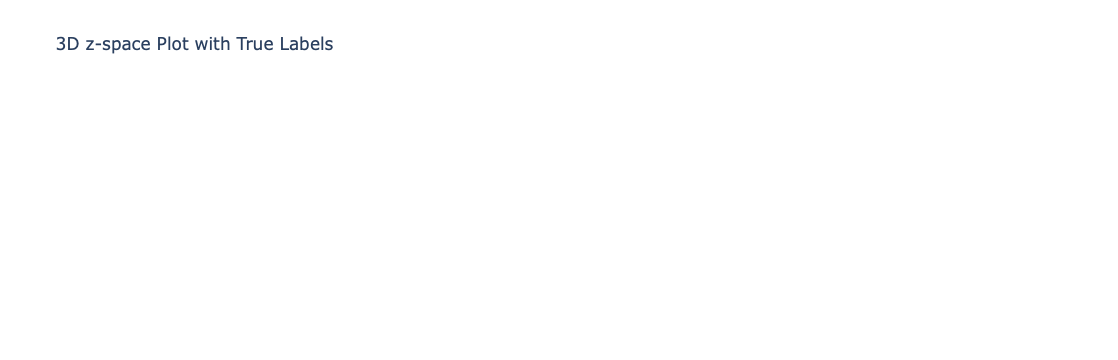

In [41]:
import plotly.graph_objects as go

z_0 = dist_v_opt_transformed[:, 0]
z_1 = dist_v_opt_transformed[:, 1]
z_2 = dist_v_opt_transformed[:, 2]  

node_true_labels = original_label[node_indices[spec_node]]
unique_labels = np.unique(node_true_labels)

# Define a fixed color map for each cluster
color_map = {
    0: "lightgrey",
    1: "red",
    2: "blue",
    3: "green",
    4: "orange",
    5: "purple"
}

# Assign colors based on cluster labels
point_colors = [color_map[label] for label in node_true_labels]

# Create hover text for each point
hover_text = [
    "Background" if label == 0 else f"Cluster {label}" 
    for label in node_true_labels
]
# Create the 3D scatter plot
fig = go.Figure(data=[
    go.Scatter3d(
        x=z_0,
        y=z_1,
        z=z_2,
        mode='markers',
        marker=dict(
            size=3,
            color=point_colors,  # Directly use color names
            opacity=0.2
        ),
        text=hover_text,  # Add hover text
        hoverinfo='text'  # Display only the hover text
    )
])

# Add plot layout
fig.update_layout(
    title="3D z-space Plot with True Labels",
    scene=dict(
        xaxis_title='MDS[:, 0]',
        yaxis_title='MDS[:, 1]',
        zaxis_title='MDS[:, 2]'
    )
)

# Show the plot
fig.show()

### Kmeans on every z in iteration

Initializing probabilities randomly with 4 clusters...


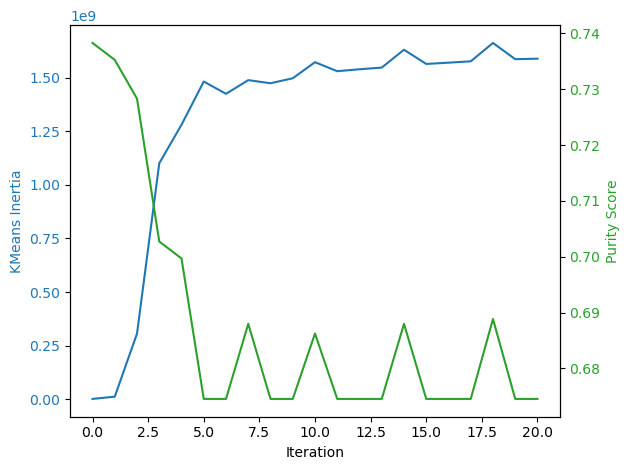

In [43]:
from sklearn.cluster import KMeans

def compute_purity_score(true_labels, predicted_labels):
    contingency_matrix = np.zeros((len(np.unique(true_labels)), len(np.unique(predicted_labels))))
    for i, true_label in enumerate(np.unique(true_labels)):
        for j, pred_label in enumerate(np.unique(predicted_labels)):
            contingency_matrix[i, j] = np.sum((true_labels == true_label) & (predicted_labels == pred_label))
    return  np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix) #np.sum(np.max(contingency_matrix, axis=0)) / len(true_labels)


initial_partition=None
theta=0.01
epsilon=0.005
rho_multiplier=np.ones(node_indices[spec_node].size, dtype=np.float32)

##from run_softmax() fct from SemiMetricDensity.py
Gamma = np.copy(smc.G)
# Normalize Gamma
Gamma /= np.std(Gamma)
# Set g[i,i] = 0 for all i
np.fill_diagonal(Gamma, 0)
n = Gamma.shape[0]
# Use the initial partition if provided, otherwise initialize randomly
if initial_partition is not None:
    p_i = initial_partition
else:
    print(f'Initializing probabilities randomly with {smc.K} clusters...')
    p_i = np.random.dirichlet(np.ones(smc.K), size=n)

if rho_multiplier is None:
    rho_multiplier = np.ones(n)

labels_prev = np.ones(n) * -1
z = np.zeros((n, smc.K))  # for covariance

#for Kmeans
inertias = []
purity_scores = []

for iteration in range(smc.max_iter):
    # Compute covariance (z) for all points and clusters
    # rho_multiplier is used to scale down importance of likely noise points
    z = Gamma @ (p_i.T * rho_multiplier).T
    # Stabilize softmax computation
    z_max = np.max(theta * z, axis=1, keepdims=True)

    ##run Kmeans on z and compute purity score
    kmeans = KMeans(n_clusters=len(unique_labels))
    kmeans.fit(z)
    inertia = kmeans.inertia_ # Measure of the internal compactness of the clusters
    inertias.append(inertia)
    cluster_labels = kmeans.labels_
    purity_score = compute_purity_score(node_true_labels, cluster_labels)
    purity_scores.append(purity_score)

   # print(f"Iteration {iteration + 1}: Inertia = {inertia}, Purity Score = {purity_score:.4f}")

    p_t = np.exp(theta * z - z_max) * p_i
    p_i = p_t / (np.sum(p_t, axis=1, keepdims=True) + 1e-10)
    theta += epsilon
    # If pi changes insignificantly, stop
    labels_i = smc.get_clusters(p_i)
    if iteration > 0 and nmi(labels_i, labels_prev) > 0.99:
        break
    prev_pi = p_i.copy()
    labels_prev = smc.get_clusters(prev_pi)
   
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('KMeans Inertia', color=color)
ax1.plot(range(len(inertias)), inertias, label='Inertia', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Purity Score', color=color)
ax2.plot(range(len(purity_scores)), purity_scores, label='Purity Score', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()